In [1]:
import numpy as np
import pickle, os 
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath
import pandas as pd  

In [2]:
projectPath, mainResultsPath = setProjectPath()

dataset_name = 'MDTB' # or Demand

# defining ROIs
large_ROI = 'PFC'
# large_ROI = 'visual'
# large_ROI = 'somatosensory'
# large_ROI = 'parietal'

resultsPath = os.path.join(mainResultsPath, 'START_B4_parcellation_sanity', dataset_name)
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

output = dict()
PKL_output = os.path.join(resultsPath, f'{dataset_name}_{large_ROI}_output.pkl')

In [3]:
PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', dataset_name, f'output_{large_ROI}.pkl')
with open(PKL_individualized_parcellation, 'rb') as pf:
    output_indiv = pickle.load(pf)
    U_indiv_label = output_indiv['indiv_parcellation']  # n_subjects x P
    U_group_label = output_indiv['group_parcellation']
    V = output_indiv['V'].T                             # n_parcels x n_conditions

In [4]:
import sys

np.set_printoptions(threshold=sys.maxsize)

In [5]:
n_subjects, P = U_indiv_label.shape
n_parcels = V.shape[1]

# count the number of parcels for each individual
n_parcels_per_indiv = []
n_vertices_per_parcel = []
for subjI in np.arange(n_subjects):
    vals, counts = np.unique(U_indiv_label[subjI], return_counts=True)
    n_parcels_per_indiv.append(len(vals))
    n_vertices_per_parcel.append(counts) 

n_parcels_per_indiv = np.array(n_parcels_per_indiv)
n_vertices_per_parcel = np.array(n_vertices_per_parcel)

print(n_parcels_per_indiv)


pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) 

df = pd.DataFrame(n_vertices_per_parcel)
display(df) 

[46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46]


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45
0,106,83,215,379,177,156,189,2125,240,90,112,60,62,162,65,63,225,315,109,1207,78,76,232,39,24,111,201,39,102,111,101,346,93,73,96,287,211,583,190,219,53,255,621,1611,308,47318
1,106,71,372,582,2770,91,22,23,111,57,138,13,17,59,10,546,407,214,157,181,407,177,545,108,105,115,518,130,263,34,68,111,116,36,162,193,671,856,377,67,518,121,369,131,55,47318
2,106,603,272,195,439,29,163,44,104,13,48,11,227,77,16,116,196,169,228,91,237,143,54,52,335,149,463,1918,42,74,111,278,3023,39,102,239,260,448,153,87,82,193,354,192,25,47318
3,106,128,432,244,33,137,114,73,568,146,43,58,24,47,23,364,317,823,147,458,704,379,381,132,165,323,424,76,293,76,251,369,198,29,407,235,1200,371,475,424,45,51,582,105,220,47318
4,106,46,279,216,3,232,99,57,67,1968,363,54,77,50,68,219,219,236,44,151,120,111,393,491,12,67,308,70,35,77,100,46,123,11,168,229,131,52,321,31,116,2926,726,874,108,47318
5,106,429,567,74,47,82,1596,104,47,54,99,110,72,266,117,274,459,230,1370,192,79,297,149,195,346,138,251,1080,113,91,163,178,55,116,32,254,60,130,140,60,1383,88,250,68,189,47318
6,106,462,492,421,69,37,91,122,385,79,39,66,16,26,44,155,378,410,68,462,525,376,442,60,573,244,1387,100,763,94,168,597,74,48,206,221,287,396,380,137,132,25,760,141,136,47318
7,106,192,174,90,17,183,146,45,183,59,110,433,120,181,174,553,297,447,273,435,291,304,347,180,176,420,583,54,72,160,397,185,37,11,332,117,457,156,429,213,130,29,248,196,2458,47318
8,106,125,353,152,27,122,80,604,538,49,41,176,78,224,25,113,229,191,256,499,573,129,32,307,235,43,155,29,41,257,153,161,86,136,211,101,140,157,514,4063,60,10,157,142,320,47318
9,106,213,263,157,94,173,302,165,631,123,266,93,580,182,114,320,148,423,782,247,74,386,189,436,173,680,96,240,165,399,870,635,85,21,468,217,66,99,389,159,98,171,186,387,129,47318


In [6]:
# load V compute similarity between each pair of parcels
V_simmats = np.corrcoef(V)

Text(0, 0.5, 'parcels')

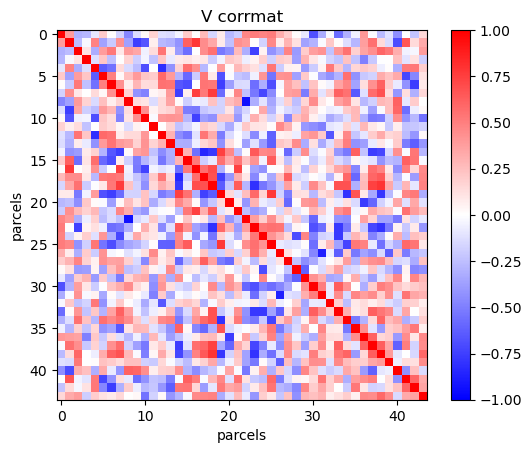

In [7]:
JPG_V_corrmat = os.path.join(resultsPath, f'V_corrmat.jpg')
fig, ax = plt.subplots(1, 1)
im = ax.imshow(V_simmats, cmap='bwr', vmin=-1, vmax=1)
ax.set_aspect('equal')
plt.colorbar(im)
ax.set_title(f'V corrmat')
ax.set_xlabel('parcels')
ax.set_ylabel('parcels')

In [8]:
output['V'] = V
output['V_simmats'] = V_simmats
output['n_parcels_per_indiv'] = n_parcels_per_indiv
output['n_vertices_per_parcel'] = n_vertices_per_parcel

In [9]:
plt.savefig(JPG_V_corrmat, dpi=400, format='jpg')

with open(PKL_output, 'wb') as pf:
    pickle.dump(output, pf)

<Figure size 640x480 with 0 Axes>